This code sample is dervied from the [Alpha Genome API](https://github.com/google-deepmind/alphagenome) quick start.

In [1]:
from alphagenome.data import genome
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt

/Users/irithkatiyar/Desktop/hst506/genai4bio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ALPHAGENOME_API_KEY = '' # TODO: FILL IN YOUR API KEY

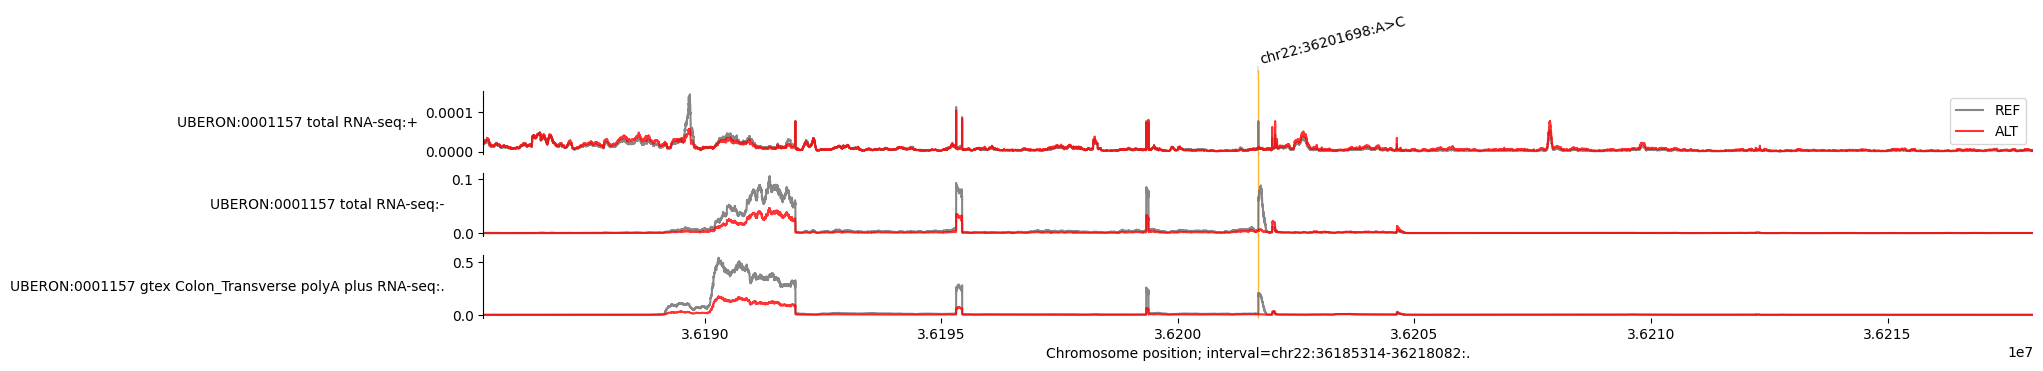

In [3]:
model = dna_client.create(ALPHAGENOME_API_KEY)

interval = genome.Interval(chromosome='chr22', start=35677410, end=36725986)
variant = genome.Variant(
    chromosome='chr22',
    position=36201698,
    reference_bases='A',
    alternate_bases='C',
)

outputs = model.predict_variant(
    interval=interval,
    variant=variant,
    ontology_terms=['UBERON:0001157'],
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
)

plot_components.plot(
    [
        plot_components.OverlaidTracks(
            tdata={
                'REF': outputs.reference.rna_seq,
                'ALT': outputs.alternate.rna_seq,
            },
            colors={'REF': 'dimgrey', 'ALT': 'red'},
        ),
    ],
    interval=outputs.reference.rna_seq.interval.resize(2**15),
    # Annotate the location of the variant as a vertical line.
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)
plt.show()